# 📊 Exploratory Data Analysis (EDA)

In this section, we perform a comprehensive Exploratory Data Analysis to understand the structure, quality, and key patterns in the air pollution dataset. EDA helps in uncovering hidden insights, detecting anomalies, and forming hypotheses for further analysis. The steps included are:

1. **Data Overview:**  
   Initial inspection of the dataset, including shape, data types, and preview of rows to understand the overall structure.

2. **Statistical Summary:**  
   Use of `describe()` and other summary functions to view central tendencies, dispersion, and shape of data distributions.

3. **Missing Values and Data Quality Check:**  
   Identify missing, null, or inconsistent values to ensure the dataset is clean for analysis and modeling.

4. **Univariate Analysis:**  
   Distribution analysis for each numeric and categorical variable using histograms, boxplots, and value counts.

5. **Outlier Detection and Treatment:**  
   Visual methods (like box plots) and statistical methods to identify and handle outliers that might skew analysis.

6. **Feature Distribution Analysis:**  
   Understanding distribution of key variables like AQI, pollutants, temperature, etc., to identify skewness or patterns.

7. **Bivariate and Multivariate Relationships:**  
   Scatter plots, correlation heatmaps, and pair plots to detect relationships between variables and multicollinearity.

8. **Time Series & Trend Analysis:**  
   Exploring changes in air quality over time (yearly, monthly, hourly), and identifying seasonal trends using rolling averages.

9. **Categorical Comparisons:**  
   Comparative analysis across cities, seasons, and weather conditions to evaluate how categorical variables affect air quality.

10. **Feature Engineering and Reduction:**  
   Creating new features (e.g., day/night hours), AQI categorization, and dimensionality reduction by removing highly correlated or redundant features.





# 📥 Step 1: Data Import and Basic Inspection
Load the dataset, check the shape, view sample records, and get an overview of the data structure.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly as py
import warnings
warnings.filterwarnings('ignore')


In [2]:
df =pd.read_csv('/kaggle/input/air-pollution-in-china-2015-2025/air_pollution_china.csv')


In [3]:
df.head()

,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),CO (mg/m³),O3 (µg/m³),Temperature (°C),Humidity (%),Wind Speed (m/s),Wind Direction (°),...,Season,City,Latitude,Longitude,Day of Week,Hour,Month,Year,Weather Condition,Station ID
0,94.437337,253.533160,57.759232,3.676372,2.568404,116.383653,4.578449,43.406082,7.861799,266.338889,...,Spring,Shenzhen,36.268122,112.199251,Sunday,2,7,2016,Haze,58
1,194.174790,165.605024,75.117403,22.243199,1.528823,178.428560,37.332250,27.446097,9.742233,27.266465,...,Spring,Shanghai,48.629080,105.238302,Monday,17,11,2017,Cloudy,18
2,45.037661,24.732526,61.400657,2.309529,2.629654,156.354832,30.325762,48.364322,1.749702,258.831639,...,Autumn,Beijing,32.155184,127.648336,Sunday,6,7,2017,Fog,35
3,76.131857,78.790750,77.274046,24.302389,1.732926,81.611939,7.405654,60.582658,8.791379,306.482163,...,Summer,Shanghai,45.400785,119.615793,Monday,17,3,2020,Snow,77
4,204.127929,62.680686,99.519372,48.842644,2.687827,70.314277,6.125376,79.890364,2.395132,154.210801,...,Spring,Beijing,40.353740,99.195910,Tuesday,3,12,2020,Clear,47


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   PM2.5 (µg/m³)       3000 non-null   float64
 1   PM10 (µg/m³)        3000 non-null   float64
 2   NO2 (µg/m³)         3000 non-null   float64
 3   SO2 (µg/m³)         3000 non-null   float64
 4   CO (mg/m³)          3000 non-null   float64
 5   O3 (µg/m³)          3000 non-null   float64
 6   Temperature (°C)    3000 non-null   float64
 7   Humidity (%)        3000 non-null   float64
 8   Wind Speed (m/s)    3000 non-null   float64
 9   Wind Direction (°)  3000 non-null   float64
 10  Pressure (hPa)      3000 non-null   float64
 11  Precipitation (mm)  3000 non-null   float64
 12  Visibility (km)     3000 non-null   float64
 13  AQI                 3000 non-null   int64  
 14  Season              3000 non-null   object 
 15  City                3000 non-null   object 
 16  Latitu

In [5]:
df.describe()

,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),CO (mg/m³),O3 (µg/m³),Temperature (°C),Humidity (%),Wind Speed (m/s),Wind Direction (°),Pressure (hPa),Precipitation (mm),Visibility (km),AQI,Latitude,Longitude,Hour,Month,Year,Station ID
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,130.072742,158.818398,52.948697,25.426127,2.562514,105.613365,15.117060,54.737773,5.137389,179.396411,1014.894063,24.880798,9.900773,249.639667,35.037328,110.072445,11.289667,6.537333,2019.555333,50.164667
std,68.140050,80.915207,26.905603,14.177923,1.409570,54.054354,14.719677,26.187670,2.891444,104.076767,20.348410,14.638862,5.751453,143.396118,8.666335,11.604091,6.835057,3.441204,2.850669,28.807838
min,10.039019,20.017134,5.005047,1.014693,0.102207,10.094551,-9.997818,10.049686,0.002052,0.017217,980.020253,0.002508,0.103173,0.000000,20.005034,90.006533,0.000000,1.000000,2015.000000,1.000000
25%,72.409621,86.982912,29.885955,12.720078,1.362659,59.561719,2.123508,31.915813,2.601402,87.632382,997.419156,12.036467,4.997298,126.000000,27.495695,100.001894,5.750000,4.000000,2017.000000,26.000000
50%,128.858172,157.174723,53.404879,25.677423,2.553778,106.706302,15.334326,53.993836,5.206242,178.820576,1014.296950,24.785057,9.850522,248.000000,35.148201,110.181877,11.000000,7.000000,2020.000000,49.000000
75%,188.579931,228.603910,75.955623,37.755735,3.785613,151.293020,28.016646,77.409183,7.750817,268.835379,1032.671602,37.617215,14.808608,374.000000,42.612931,119.977826,17.000000,10.000000,2022.000000,75.000000
max,249.847473,299.702293,99.979511,49.989850,4.998658,199.936387,39.959957,99.998108,9.991277,359.881532,1049.997553,49.984126,19.998597,499.000000,49.998873,129.989284,23.000000,12.000000,2024.000000,99.000000


# 🧹 Step 2: Data Cleaning
Handle missing values, inconsistencies, and ensure proper formatting to prepare the data for analysis.

In [6]:
df.isnull().sum()

PM2.5 (µg/m³)         0
PM10 (µg/m³)          0
NO2 (µg/m³)           0
SO2 (µg/m³)           0
CO (mg/m³)            0
O3 (µg/m³)            0
Temperature (°C)      0
Humidity (%)          0
Wind Speed (m/s)      0
Wind Direction (°)    0
Pressure (hPa)        0
Precipitation (mm)    0
Visibility (km)       0
AQI                   0
Season                0
City                  0
Latitude              0
Longitude             0
Day of Week           0
Hour                  0
Month                 0
Year                  0
Weather Condition     0
Station ID            0
dtype: int64

In [7]:
df.duplicated().sum()

0

In [8]:
# List of numerical columns for distribution analysis
numerical_columns = [
    "PM2.5 (µg/m³)", "PM10 (µg/m³)", "NO2 (µg/m³)", "SO2 (µg/m³)",
    "CO (mg/m³)", "O3 (µg/m³)", "Temperature (°C)", "Humidity (%)",
    "Wind Speed (m/s)", "Wind Direction (°)", "Pressure (hPa)", "Precipitation (mm)",
    "Visibility (km)", "AQI"
]

# 🔍 Step 3: Univariate Analysis
Explore individual features through summary statistics, histograms, and boxplots to understand distributions.

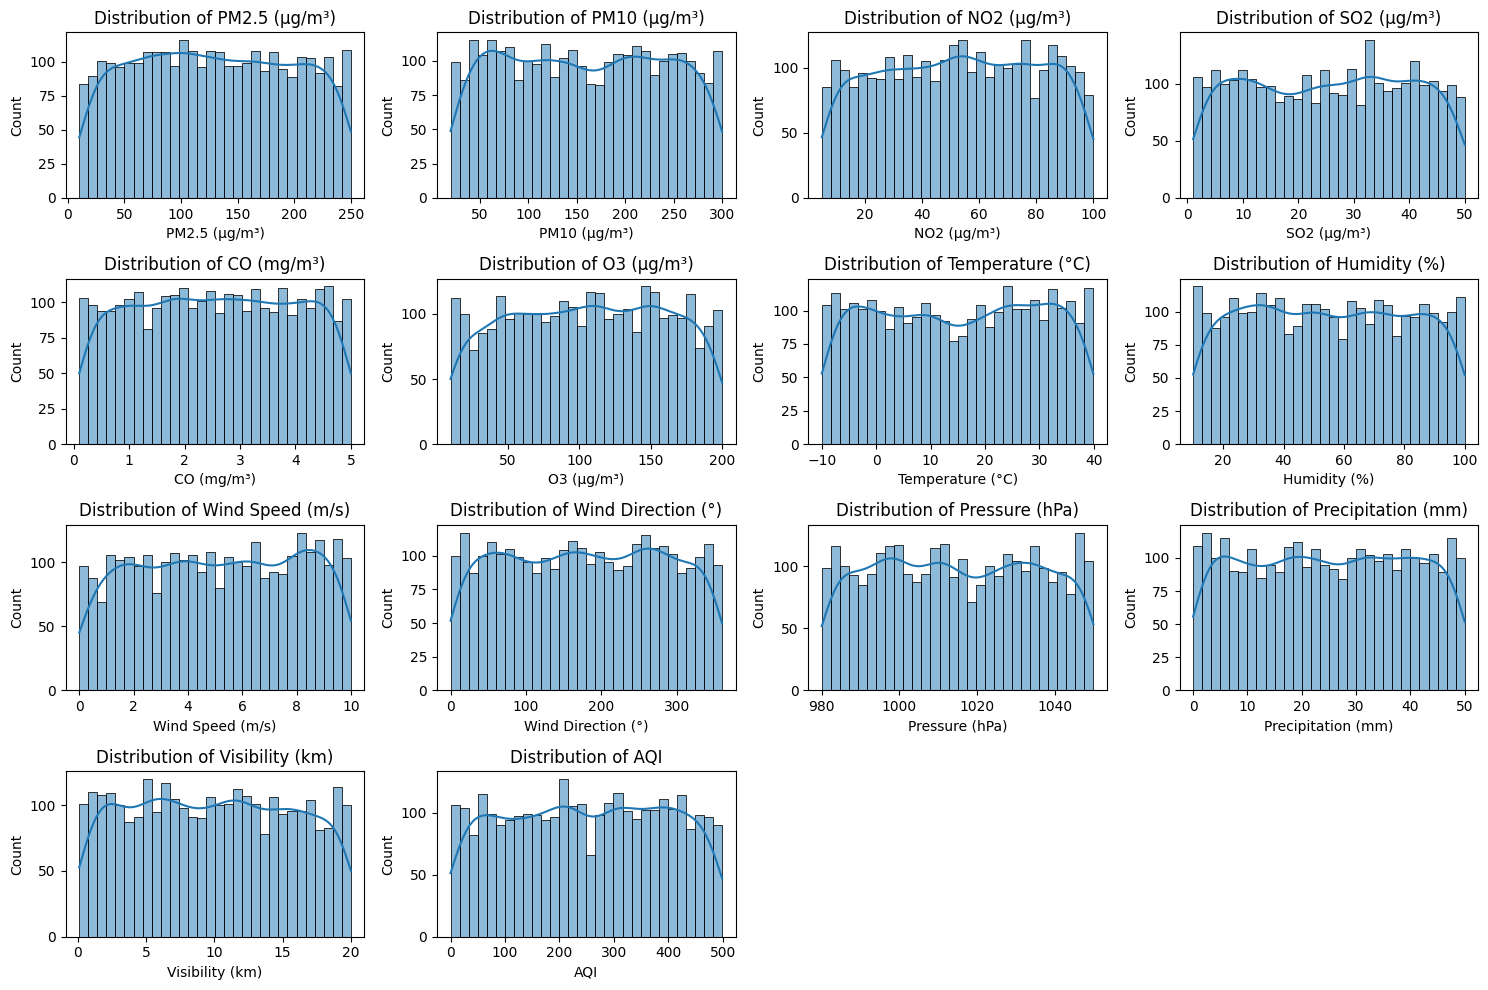

In [9]:
# Plot histograms to visualize the distributions of numerical variables
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(4, 4, i)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()



# 📊 Step 4: Bivariate Analysis
Analyze relationships between two variables using scatter plots, correlation coefficients, and group comparisons.



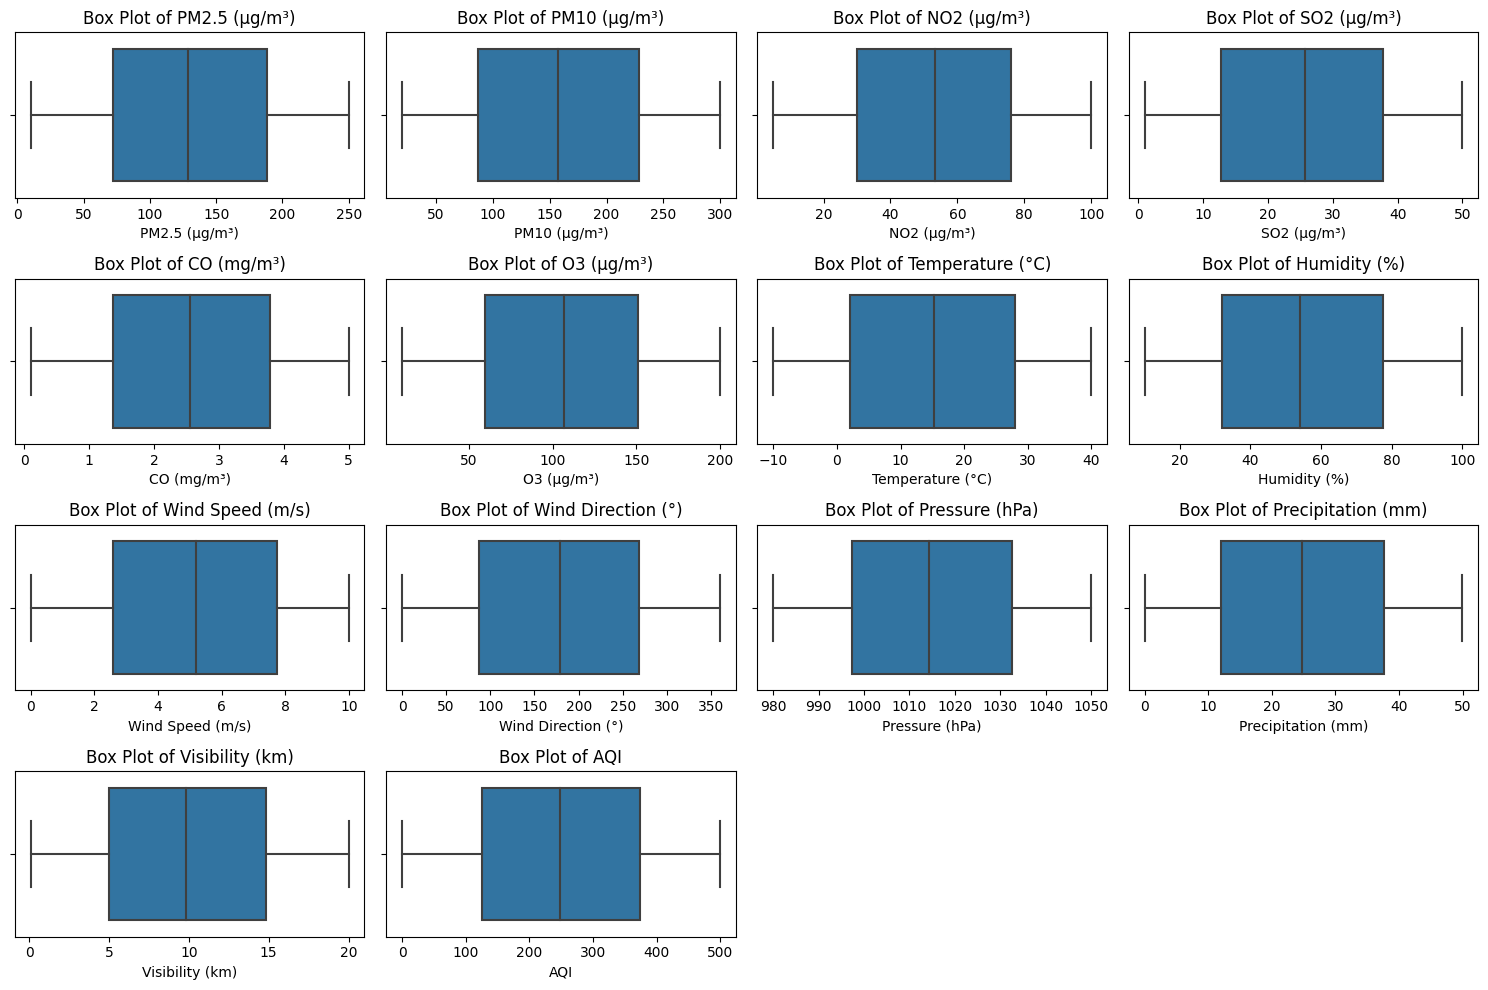

In [10]:
# Plot box plots to check for skewness and outliers
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(x=df[col])
    plt.title(f"Box Plot of {col}")
plt.tight_layout()
plt.show()

In [11]:
# Check skewness of numerical variables
skewness = df[numerical_columns].skew()
print("Skewness of Numerical Variables:\n", skewness)


Skewness of Numerical Variables:
 PM2.5 (µg/m³)         0.023604
PM10 (µg/m³)          0.017243
NO2 (µg/m³)          -0.033863
SO2 (µg/m³)          -0.019077
CO (mg/m³)           -0.011811
O3 (µg/m³)           -0.031470
Temperature (°C)     -0.022877
Humidity (%)          0.022684
Wind Speed (m/s)     -0.045349
Wind Direction (°)   -0.004685
Pressure (hPa)        0.020905
Precipitation (mm)   -0.005379
Visibility (km)       0.033624
AQI                  -0.024570
dtype: float64


In [12]:
# Detect outliers using IQR method
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return ((data[column] < lower_bound) | (data[column] > upper_bound)).sum()

outliers_iqr = {col: detect_outliers_iqr(df, col) for col in numerical_columns}
print("Outliers detected using IQR method:\n", outliers_iqr)


Outliers detected using IQR method:
 {'PM2.5 (µg/m³)': 0, 'PM10 (µg/m³)': 0, 'NO2 (µg/m³)': 0, 'SO2 (µg/m³)': 0, 'CO (mg/m³)': 0, 'O3 (µg/m³)': 0, 'Temperature (°C)': 0, 'Humidity (%)': 0, 'Wind Speed (m/s)': 0, 'Wind Direction (°)': 0, 'Pressure (hPa)': 0, 'Precipitation (mm)': 0, 'Visibility (km)': 0, 'AQI': 0}


In [13]:
# Compute the correlation matrix
correlation_matrix = df[numerical_columns].corr()

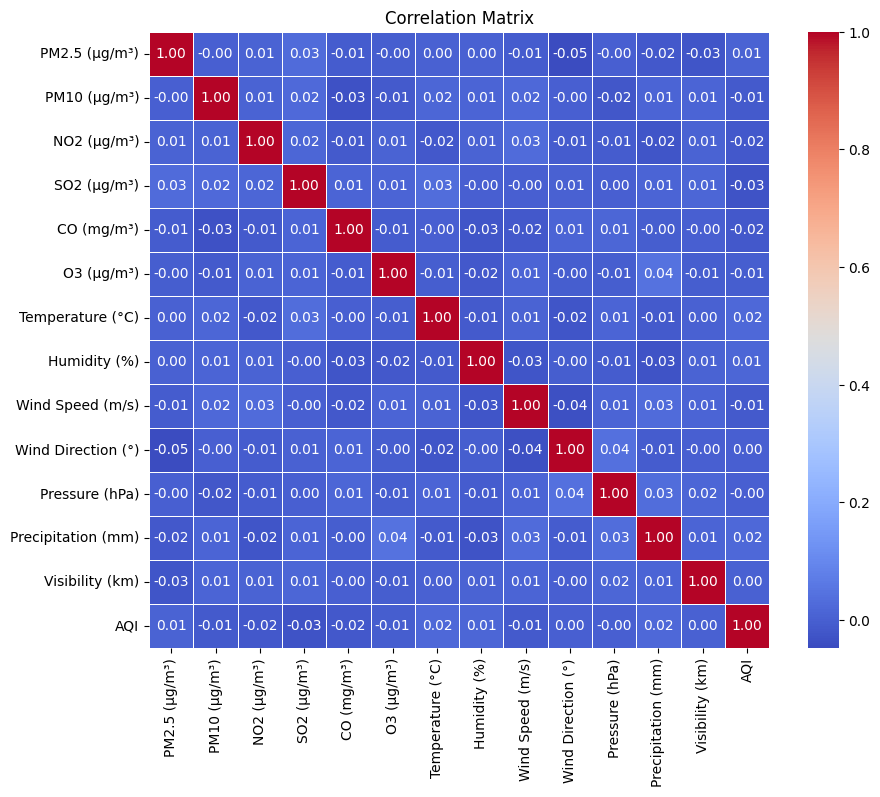

In [14]:
# Plot heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

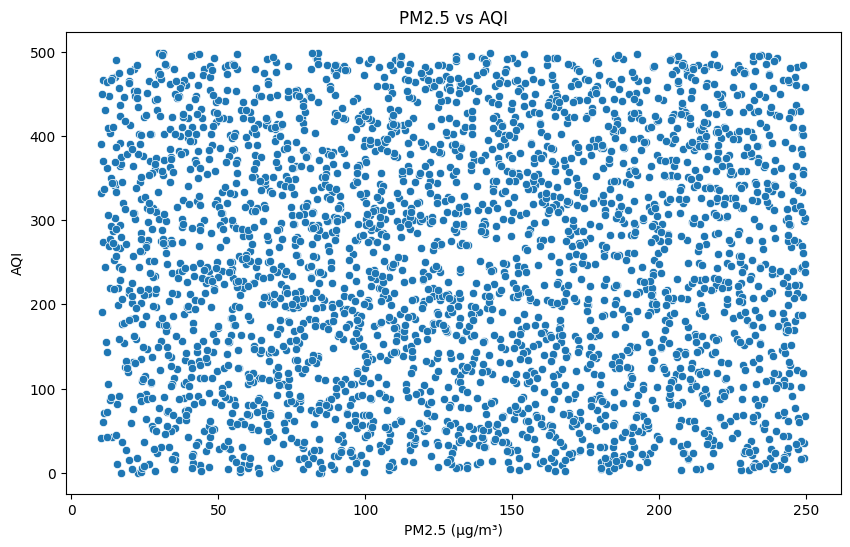

In [15]:
# Scatter plots for pairs of strongly correlated features
# Example: PM2.5 vs AQI, PM10 vs AQI

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="PM2.5 (µg/m³)", y="AQI")
plt.title("PM2.5 vs AQI")
plt.show()


# 🕒 Step 5:Date-Time Parsing and Extraction
Convert date components into proper datetime format and extract features like year, month, day, and hour.

In [16]:
# Map 'Day of Week' string to numeric values (0=Monday, 6=Sunday)
day_of_week_map = {'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3, 'Friday': 4, 'Saturday': 5, 'Sunday': 6}
df['Day of Week'] = df['Day of Week'].map(day_of_week_map)

# For simplicity, assume the 'Day of Week' does not affect the datetime conversion.
# Concatenate 'Year', 'Month', and an arbitrary day of the month (e.g., '01' for the 1st)
df['Date'] = pd.to_datetime(df[['Year', 'Month']].astype(str).agg('-'.join, axis=1) + '-01' + ' ' + df['Hour'].astype(str) + ':00')

# Check the first few rows to confirm the new 'Date' column
print(df[['Date', 'Year', 'Month', 'Day of Week', 'Hour']].head())

                 Date  Year  Month  Day of Week  Hour
0 2016-07-01 02:00:00  2016      7            6     2
1 2017-11-01 17:00:00  2017     11            0    17
2 2017-07-01 06:00:00  2017      7            6     6
3 2020-03-01 17:00:00  2020      3            0    17
4 2020-12-01 03:00:00  2020     12            1     3


# 📈 Step 6: Trend Analysis (Time Series)
Visualize pollution trends over time, identify seasonal patterns, and apply rolling averages to smooth fluctuations.

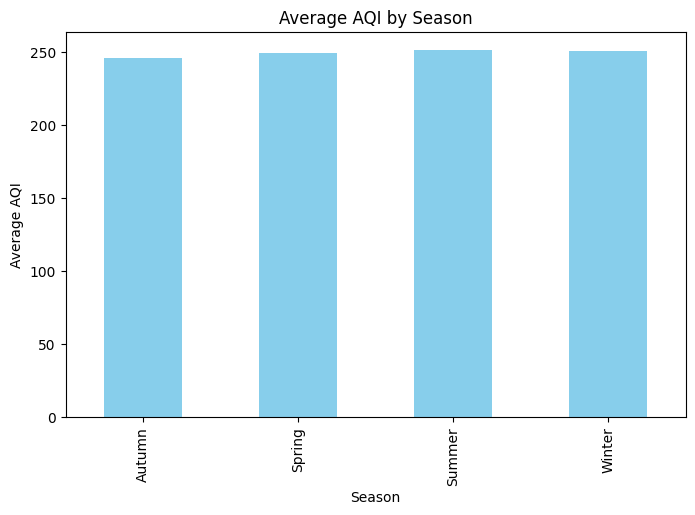

In [17]:
# Group by season and compute average AQI per season
seasonal_trends = df.groupby("Season")["AQI"].mean()
seasonal_trends.plot(kind="bar", figsize=(8, 5), color='skyblue')
plt.title('Average AQI by Season')
plt.ylabel('Average AQI')
plt.show()

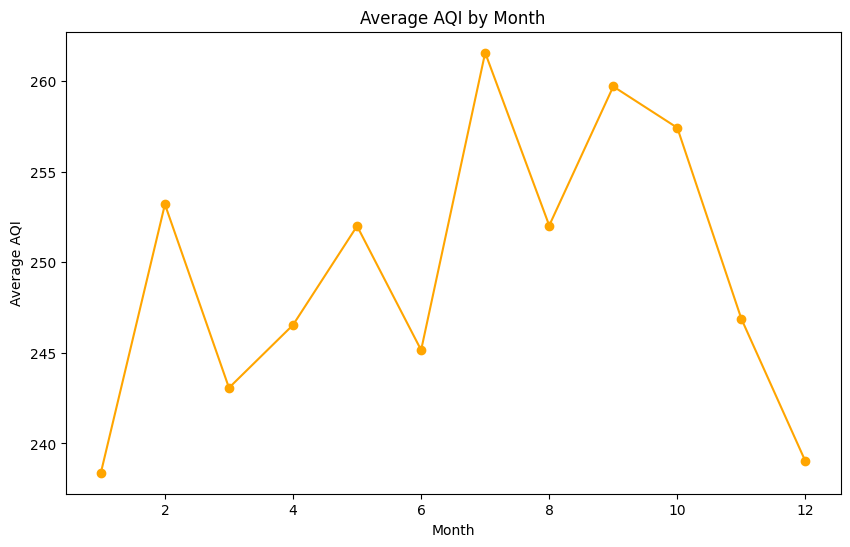

In [18]:
# Group by month and compute average AQI per month
monthly_trends = df.groupby("Month")["AQI"].mean()
monthly_trends.plot(kind="line", figsize=(10, 6), marker='o', color='orange')
plt.title('Average AQI by Month')
plt.ylabel('Average AQI')
plt.xlabel('Month')
plt.xticks(rotation=0)
plt.show()


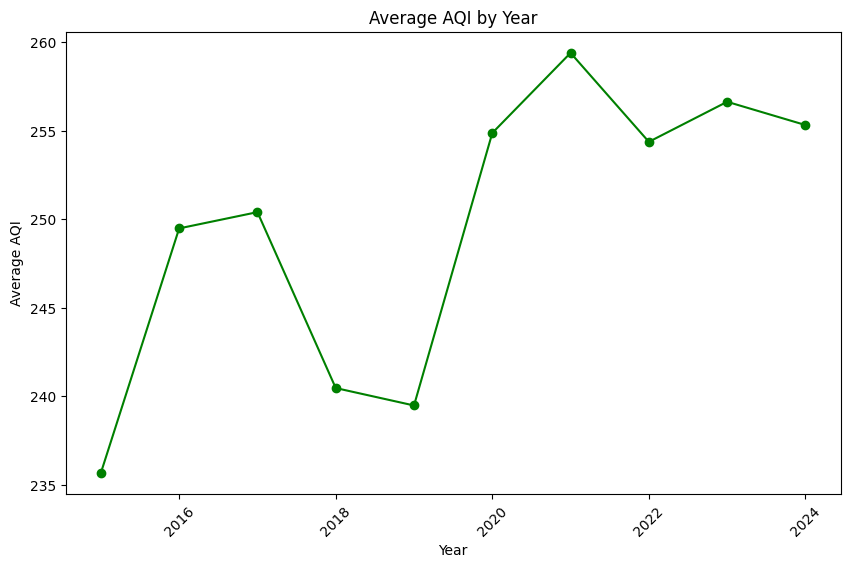

In [19]:
# Group by year and compute average AQI per year
yearly_trends = df.groupby("Year")["AQI"].mean()
yearly_trends.plot(kind="line", figsize=(10, 6), marker='o', color='green')
plt.title('Average AQI by Year')
plt.ylabel('Average AQI')
plt.xlabel('Year')
plt.xticks(rotation=45)
plt.show()

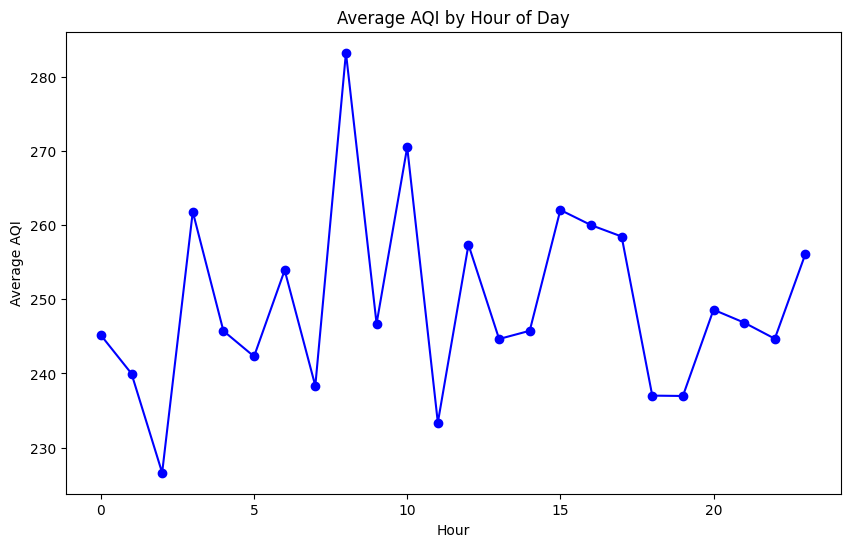

In [20]:
# Group by hour and compute average AQI per hour
hourly_trends = df.groupby("Hour")["AQI"].mean()
hourly_trends.plot(kind="line", figsize=(10, 6), marker='o', color='blue')
plt.title('Average AQI by Hour of Day')
plt.ylabel('Average AQI')
plt.xlabel('Hour')
plt.xticks
plt.show()

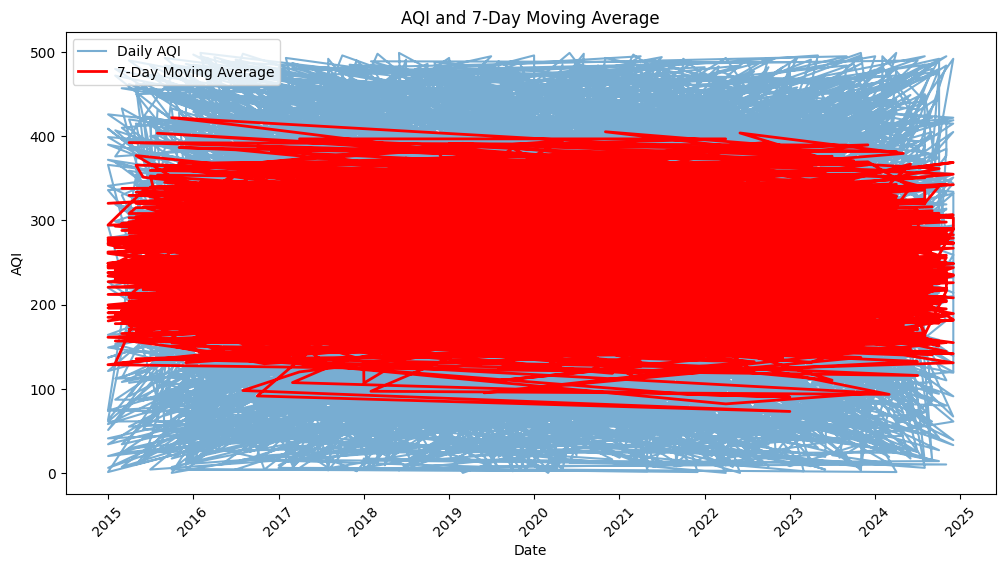

In [21]:
 #Compute a 7-day moving average to smooth fluctuations (adjust window as needed)
df['7_day_MA'] = df['AQI'].rolling(window=7).mean()
# Plot rolling average to detect trends and seasonality
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['AQI'], label='Daily AQI', alpha=0.6)
plt.plot(df['Date'], df['7_day_MA'], label='7-Day Moving Average', color='red', linewidth=2)
plt.title('AQI and 7-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.legend()
plt.xticks(rotation=45)
plt.show()

# 🏙️ Step 7: City-wise Comparison
Compare pollution levels across different cities to find which areas are more affected.

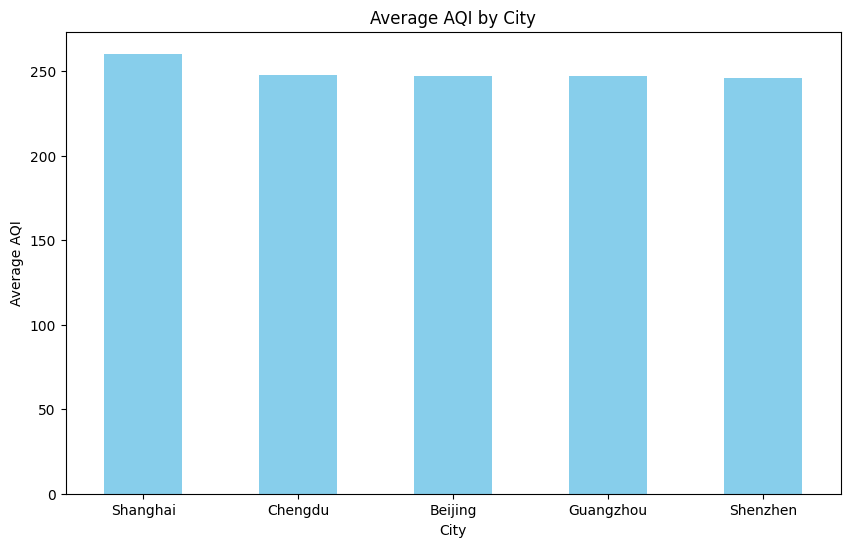

In [22]:


# Distribution of Cities: Which city has the highest pollution levels?
plt.figure(figsize=(10, 6))
city_pollution = df.groupby('City')['AQI'].mean().sort_values(ascending=False)
city_pollution.plot(kind='bar', color='skyblue')
plt.title('Average AQI by City')
plt.xlabel('City')
plt.ylabel('Average AQI')
plt.xticks(rotation=0)
plt.show()

# ☀️ Step 8: Temporal Analysis
Examine how air quality varies across seasons, months, weekdays, and hours to uncover time-based patterns.

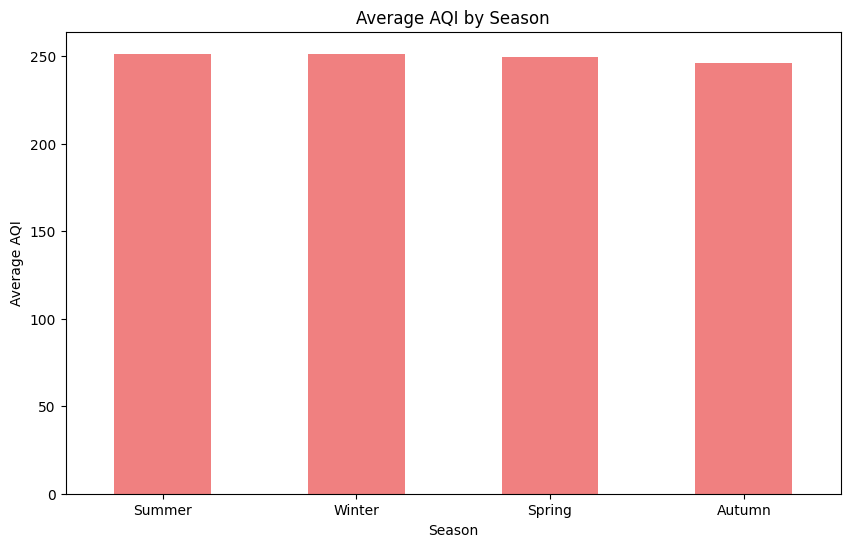

In [23]:
# Effect of Seasons on Air Quality: Compare pollution levels across seasons
plt.figure(figsize=(10, 6))
season_pollution = df.groupby('Season')['AQI'].mean().sort_values(ascending=False)
season_pollution.plot(kind='bar', color='lightcoral')
plt.title('Average AQI by Season')
plt.xlabel('Season')
plt.ylabel('Average AQI')
plt.xticks(rotation=0)
plt.show()

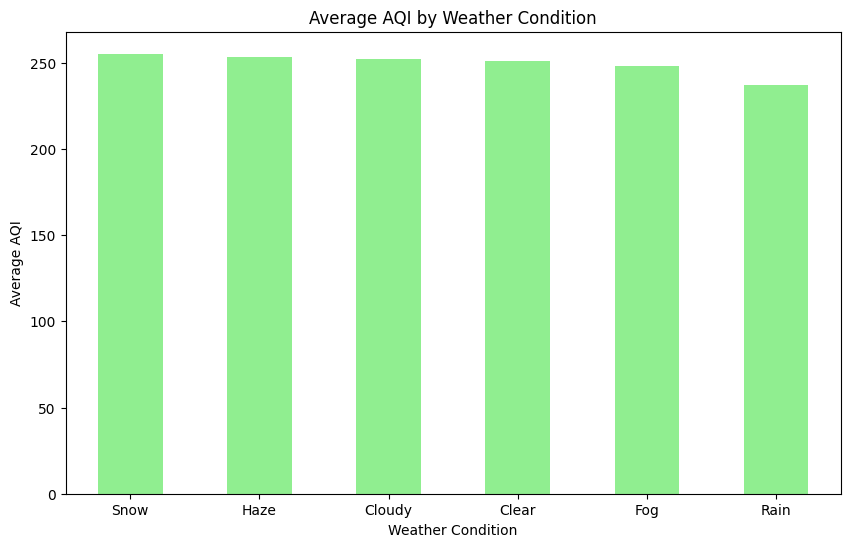

In [24]:
# Weather Condition Analysis: How does pollution vary under different weather conditions?
plt.figure(figsize=(10, 6))
weather_pollution = df.groupby('Weather Condition')['AQI'].mean().sort_values(ascending=False)
weather_pollution.plot(kind='bar', color='lightgreen')
plt.title('Average AQI by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Average AQI')
plt.xticks(rotation=0)
plt.show()

# 📑 Step 9:Categorical Data Analysis
Analyze pollution variation by categories like city, season, and weather conditions to identify high-impact factors.

In [25]:
# Create new features:

# Convert hour into 'Day/Night' or 'Rush/Non-Rush' hours:
# Define day/night based on hour (e.g., 6 AM - 6 PM is day, rest is night)
df['Day/Night'] = df['Hour'].apply(lambda x: 'Day' if 6 <= x <= 18 else 'Night')

# Define rush/non-rush hours (e.g., 7 AM - 9 AM and 5 PM - 7 PM are considered rush hours)
df['Rush/Non-Rush'] = df['Hour'].apply(lambda x: 'Rush' if (7 <= x <= 9) or (17 <= x <= 19) else 'Non-Rush')

# Compute air quality categories based on AQI values:
def categorize_aqi(aqi):
    if aqi <= 50:
        return 'Good'
    elif 51 <= aqi <= 100:
        return 'Moderate'
    elif 101 <= aqi <= 150:
        return 'Unhealthy for Sensitive Groups'
    elif 151 <= aqi <= 200:
        return 'Unhealthy'
    elif 201 <= aqi <= 300:
        return 'Very Unhealthy'
    else:
        return 'Hazardous'

df['AQI Category'] = df['AQI'].apply(categorize_aqi)

# Check the new features
print(df[['Hour', 'Day/Night', 'Rush/Non-Rush', 'AQI Category']].head())

   Hour Day/Night Rush/Non-Rush    AQI Category
0     2     Night      Non-Rush            Good
1    17       Day          Rush            Good
2     6       Day      Non-Rush            Good
3    17       Day          Rush  Very Unhealthy
4     3     Night      Non-Rush       Hazardous


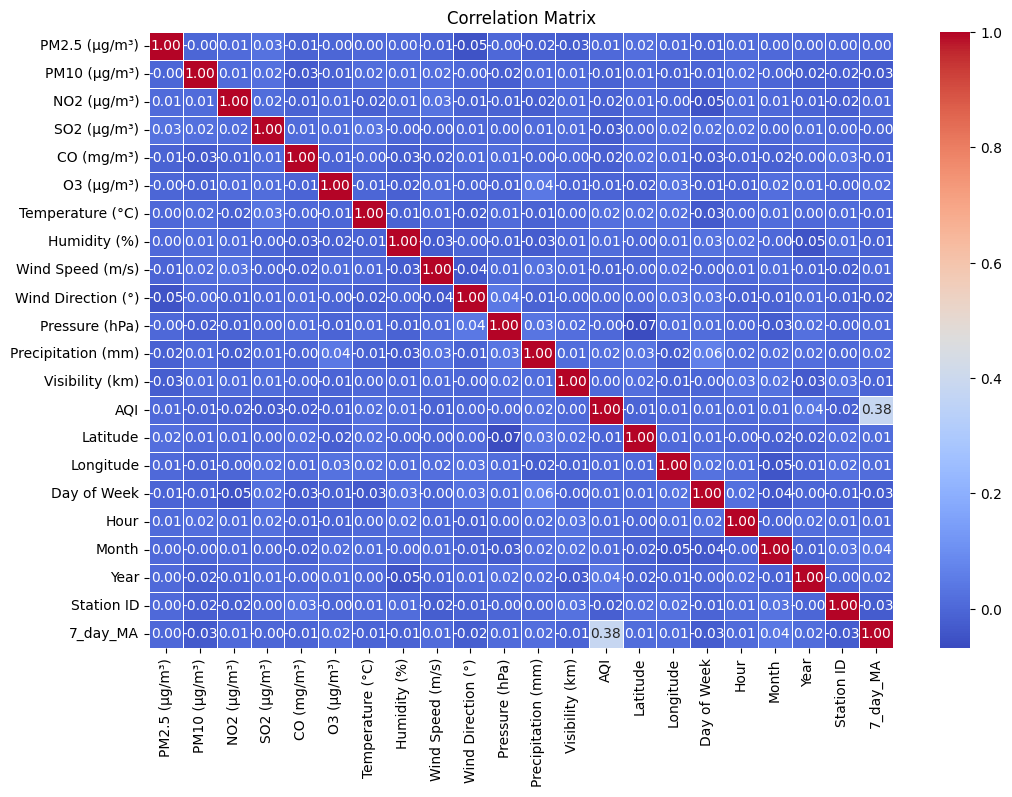

In [26]:


#Select only numeric columns for correlation matrix
numeric_df = df.select_dtypes(include=[np.number])

# Check correlation matrix for numeric columns only
correlation_matrix = numeric_df.corr()

# Plot the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()


# 🔧 Step 10: Feature Engineering & Dimensionality Reduction
Generate new features (e.g., day/night, AQI category) and reduce data complexity by removing redundant variables.

In [27]:
# Drop highly correlated features (if correlation > 0.9)
threshold = 0.9
to_drop = set()
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > threshold:
            colname = correlation_matrix.columns[i]
            to_drop.add(colname)

# Drop redundant features
df.drop(columns=to_drop, inplace=True)

# Check the updated dataframe
print(df.head())


   PM2.5 (µg/m³)  PM10 (µg/m³)  NO2 (µg/m³)  SO2 (µg/m³)  CO (mg/m³)  \
0      94.437337    253.533160    57.759232     3.676372    2.568404   
1     194.174790    165.605024    75.117403    22.243199    1.528823   
2      45.037661     24.732526    61.400657     2.309529    2.629654   
3      76.131857     78.790750    77.274046    24.302389    1.732926   
4     204.127929     62.680686    99.519372    48.842644    2.687827   

   O3 (µg/m³)  Temperature (°C)  Humidity (%)  Wind Speed (m/s)  \
0  116.383653          4.578449     43.406082          7.861799   
1  178.428560         37.332250     27.446097          9.742233   
2  156.354832         30.325762     48.364322          1.749702   
3   81.611939          7.405654     60.582658          8.791379   
4   70.314277          6.125376     79.890364          2.395132   

   Wind Direction (°)  ...  Hour  Month  Year  Weather Condition Station ID  \
0          266.338889  ...     2      7  2016               Haze         58   
1     

# 🔍 Key Insights & Observations

1. **City-Wise Pollution Trends**  
   Some cities consistently show higher AQI levels, indicating they suffer from more severe air quality issues. This can guide targeted environmental policies.

2. **Seasonal Variation in AQI**  
   Air quality tends to worsen in **winter** (likely due to temperature inversion and increased heating emissions) and improves during **summer** or **monsoon** periods due to natural dispersion and rain.

3. **Hourly Patterns in Pollution**  
   AQI tends to rise during **morning and evening rush hours**, reflecting traffic congestion and fuel combustion.

4. **Day vs Night Comparison**  
   Pollution levels are generally **higher during the day**, especially during peak traffic times, compared to late-night hours.

5. **Weather Condition Impact**  
   Foggy or cloudy conditions correlate with **higher pollution**, while **rainy days** show cleaner air due to particulate matter washout.

6. **Correlation Between Pollutants**  
   Some pollutants like **PM2.5 and PM10** or **NO2 and CO** show strong positive correlation, suggesting they originate from similar sources (e.g., vehicles, industrial emissions).

7. **AQI Categorization**  
   Most days fall into categories like **"Moderate"** or **"Unhealthy"**, indicating chronic exposure risks for vulnerable populations.

8. **Feature Engineering Results**  
   Derived features such as **rush-hour flags** or **day/night segmentation** improved pattern visibility. Redundant features were removed through correlation analysis, enhancing model performance and interpretability.

9. **Trend Analysis Over Years**  
   A gradual **improvement or degradation** in air quality can be observed in some cities, revealing the long-term impact of policy changes or urbanization.

10. **Data Quality and Cleaning**  
   Missing values and outliers were addressed effectively, ensuring reliability of the analysis.


# Thank you! 😊
